In [2]:
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df = pd.read_csv("automobile_sales.csv")

In [5]:
df.columns

Index(['Date', 'Year', 'Month', 'Recession', 'Consumer_Confidence',
       'Seasonality_Weight', 'Price', 'Advertising_Expenditure', 'Competition',
       'GDP', 'Growth_Rate', 'unemployment_rate', 'Automobile_Sales',
       'Vehicle_Type', 'City'],
      dtype='object')

In [6]:
df.describe()

,Year,Recession,Consumer_Confidence,Seasonality_Weight,Price,Advertising_Expenditure,Competition,GDP,Growth_Rate,unemployment_rate,Automobile_Sales
count,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000
mean,2001.520833,0.224432,101.210890,0.737756,41469.506155,2879.743655,6.118845,40.205748,-0.237074,2.441525,3164.160511
std,12.535031,0.417306,10.634092,0.286092,21388.409141,1175.338324,1.964292,16.291271,0.859691,1.108472,3640.137399
min,1980.000000,0.000000,73.900000,0.250000,15001.000000,494.200000,3.000000,12.510000,-4.230000,1.000000,40.000000
25%,1991.000000,0.000000,94.060000,0.500000,22039.000000,1872.000000,4.000000,27.210000,-0.570000,1.600000,923.000000
50%,2002.000000,0.000000,100.800000,0.810000,34957.500000,2883.500000,6.000000,39.420000,-0.005000,2.300000,2381.500000
75%,2012.000000,0.000000,108.320000,0.940000,57418.250000,3902.425000,8.000000,53.862500,0.392500,2.900000,4363.500000
max,2023.000000,1.000000,131.670000,1.500000,79998.000000,4983.000000,9.000000,70.370000,0.820000,6.000000,65645.000000


In [7]:
df.head()

,Date,Year,Month,Recession,Consumer_Confidence,Seasonality_Weight,Price,Advertising_Expenditure,Competition,GDP,Growth_Rate,unemployment_rate,Automobile_Sales,Vehicle_Type,City
0,1980-01-31,1980,Jan,1,108.24,0.45,27704,1417.5,7,60.22,0.01,5.4,220.0,SmallFamilyCar,Georgia
1,1980-01-31,1980,Jan,1,108.24,0.45,77270,763.7,7,60.22,0.01,5.4,72.0,Sports,Georgia
2,1980-01-31,1980,Jan,1,108.24,0.36,19665,1417.5,7,60.22,0.01,5.4,238.0,SuperMiniCar,Georgia
3,1980-01-31,1980,Jan,1,108.24,0.38,36986,1417.5,7,60.22,0.01,5.4,224.0,MediumFamilyCar,Georgia
4,1980-02-29,1980,Feb,1,98.75,0.46,26609,2773.4,4,45.99,-0.31,4.8,280.0,SmallFamilyCar,New York


In [8]:
df.tail()

,Date,Year,Month,Recession,Consumer_Confidence,Seasonality_Weight,Price,Advertising_Expenditure,Competition,GDP,Growth_Rate,unemployment_rate,Automobile_Sales,Vehicle_Type,City
2107,2023-11-30,2023,Nov,0,97.09,0.90,76617,4850.0,5,27.90,0.30,2.9,2098.0,Sports,Georgia
2108,2023-12-31,2023,Dec,0,95.92,1.31,25506,2319.0,3,13.52,-1.06,2.1,7797.0,SmallFamilyCar,Georgia
2109,2023-12-31,2023,Dec,0,95.92,1.10,35319,2319.0,3,13.52,-1.06,2.1,7836.0,MediumFamilyCar,Georgia
2110,2023-12-31,2023,Dec,0,95.92,1.49,56767,2319.0,3,13.52,-1.06,2.1,7786.0,ExecutiveCar,Georgia
2111,2023-12-31,2023,Dec,0,95.92,1.43,15009,2319.0,3,13.52,-1.06,2.1,7837.0,SuperMiniCar,Georgia


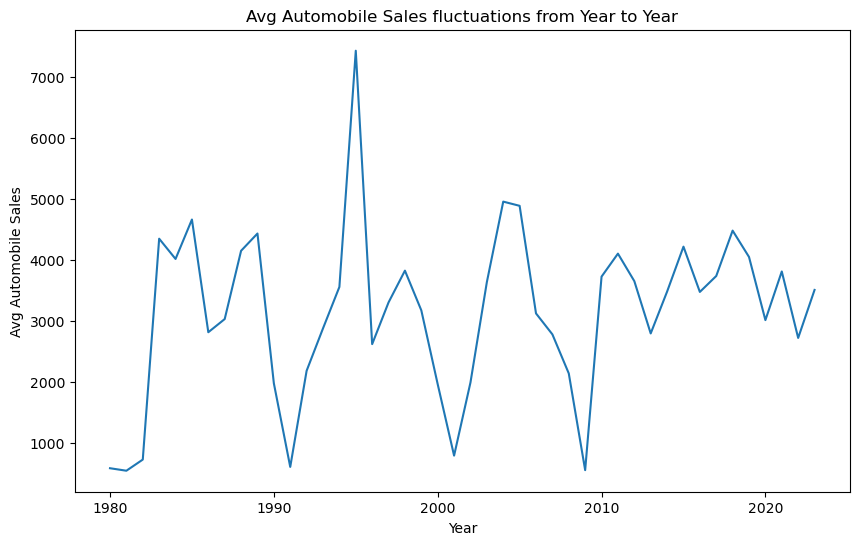

In [9]:
#Average automobile sales fluctuate from year to year. Lets visualise it 
#create data for plotting
df_line = df.groupby(df['Year'])['Automobile_Sales'].mean()
#create figure
plt.figure(figsize=(10, 6))
df_line.plot(kind = 'line')
plt.xlabel("Year")
plt.ylabel("Avg Automobile Sales")
plt.title("Avg Automobile Sales fluctuations from Year to Year")
plt.show()

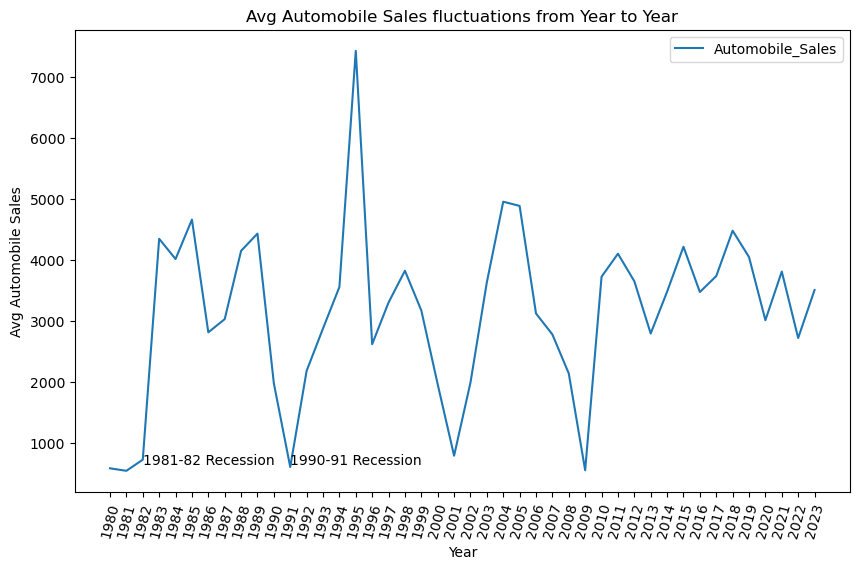

In [10]:
plt.figure(figsize=(10, 6))

df_line = df.groupby(df['Year'])['Automobile_Sales'].mean()

df_line.plot(kind = 'line')

plt.xticks(list(range(1980,2024)), rotation = 75)

plt.xlabel("Year")
plt.ylabel("Avg Automobile Sales")
plt.title("Avg Automobile Sales fluctuations from Year to Year")

plt.text(1982, 650, "1981-82 Recession")
plt.text(1991, 650, "1990-91 Recession")

plt.legend()
plt.show()

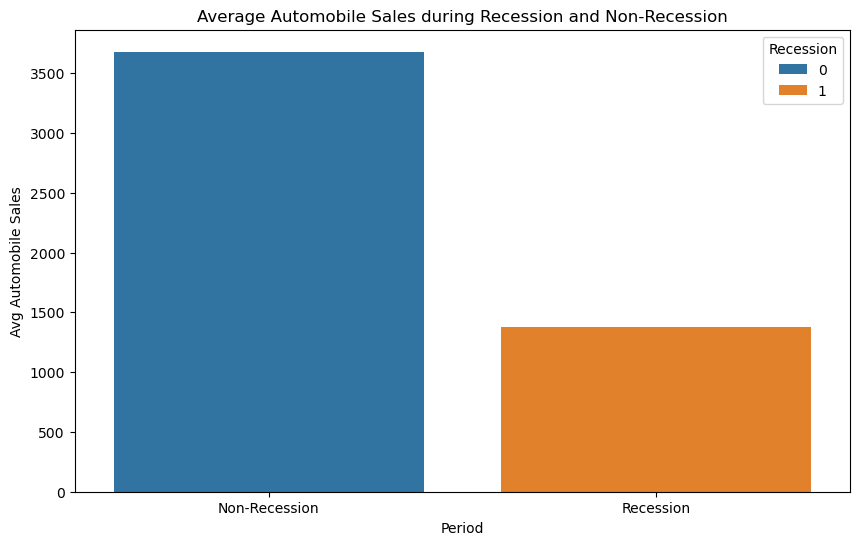

In [11]:
# visualization to compare the sales trend per vehicle type for a recession period with a non-recession period.
#thus, we need to visualize the average number of vehicles sold during recession and non-recession periods
new_df = df.groupby('Recession')['Automobile_Sales'].mean().reset_index()

# Create the bar chart using seaborn
plt.figure(figsize=(10, 6))
sns.barplot(x='Recession', y='Automobile_Sales', hue='Recession',  data=new_df)
plt.xlabel("Period")
plt.ylabel("Avg Automobile Sales")
plt.title('Average Automobile Sales during Recession and Non-Recession')
plt.xticks(ticks=[0, 1], labels=['Non-Recession', 'Recession'])
plt.show()

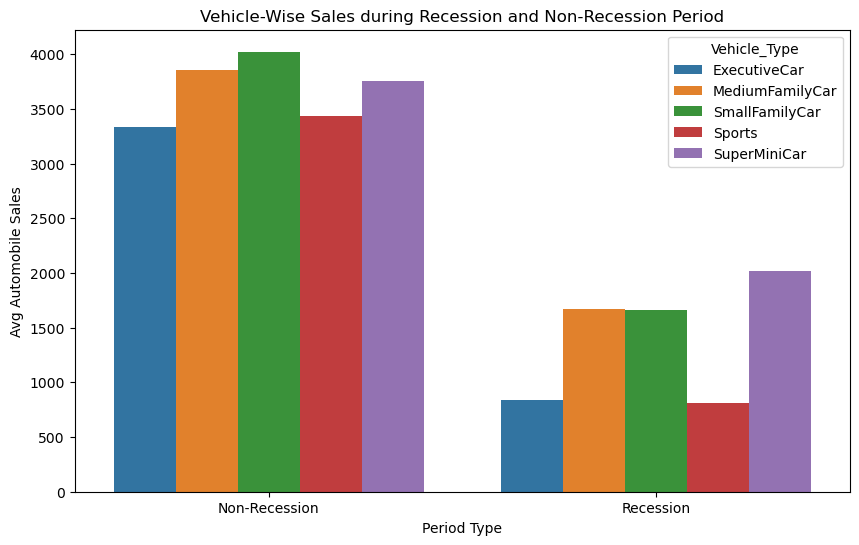

In [12]:
#compare the sales of different vehicle types during a recession and a non-recession period
grouped_df = df.groupby(['Recession','Vehicle_Type'])['Automobile_Sales'].mean().reset_index()
# Create the grouped bar chart using seaborn
plt.figure(figsize=(10, 6))
sns.barplot(x='Recession', y='Automobile_Sales', hue='Vehicle_Type', data=grouped_df)
plt.xticks(ticks=[0, 1], labels=['Non-Recession', 'Recession'])
plt.xlabel("Period Type")
plt.ylabel("Avg Automobile Sales")
plt.title('Vehicle-Wise Sales during Recession and Non-Recession Period')
plt.show()

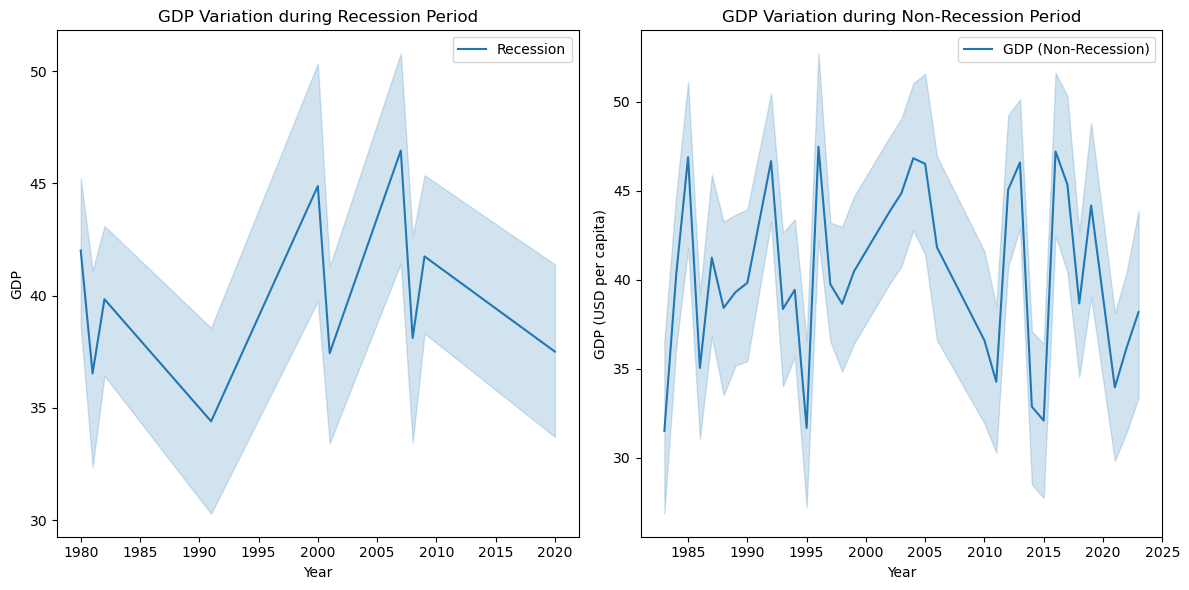

In [13]:
#Using sub plotting to compare the variations in GDP during recession and non-recession period by developing line plots for each period.

#Create dataframes for recession and non-recession period
rec_data = df[df['Recession'] == 1]
non_rec_data = df[df['Recession'] == 0]
    
#Figure
fig=plt.figure(figsize=(12, 6))
    
#Create different axes for subploting
ax0 = fig.add_subplot(1, 2, 1) 
ax1 = fig.add_subplot(1, 2, 2)  
    
#plt.subplot(1, 2, 1)
sns.lineplot(x='Year', y='GDP', data=rec_data, label='Recession', ax=ax0)
ax0.set_xlabel('Year')
ax0.set_ylabel('GDP')
ax0.set_title('GDP Variation during Recession Period')
    
#plt.subplot(1, 2, 2)
sns.lineplot(x='Year', y='GDP', data=non_rec_data, label='GDP (Non-Recession)',ax=ax1)
ax1.set_xlabel('Year')
ax1.set_ylabel('GDP (USD per capita)')
ax1.set_title('GDP Variation during Non-Recession Period')
    
plt.tight_layout()
plt.show()

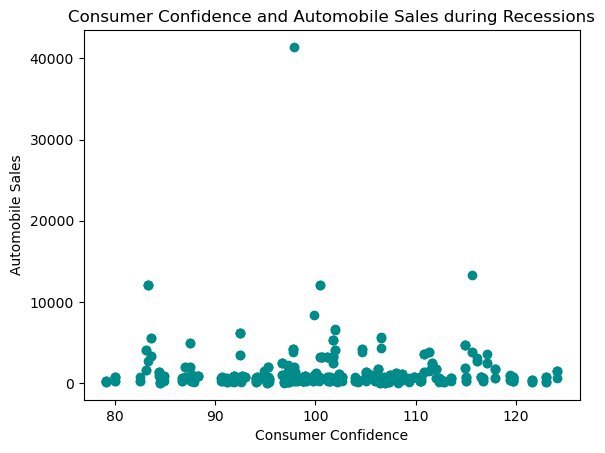

In [15]:
 #identify the relationship between consumer confidence and automobile sales during recessions.
#Create dataframes for recession and non-recession period
rec_data = df[df['Recession'] == 1]
plt.scatter(rec_data['Consumer_Confidence'], rec_data['Automobile_Sales'],color = 'darkcyan')
    
plt.xlabel('Consumer Confidence')
plt.ylabel('Automobile Sales')
plt.title('Consumer Confidence and Automobile Sales during Recessions')
plt.show()

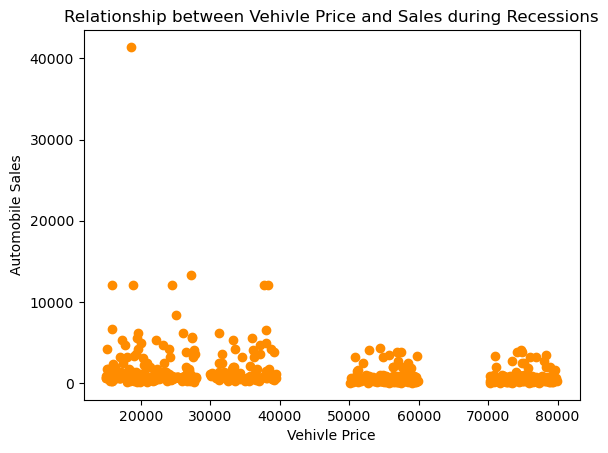

In [16]:
#'Relationship between Vehicle Price and Sales during Recessions'
#Create dataframes for recession and non-recession period
rec_data = df[df['Recession'] == 1]
plt.scatter(rec_data['Price'], rec_data['Automobile_Sales'],color = '#FF8C00')
    
plt.xlabel('Vehivle Price')
plt.ylabel('Automobile Sales')
plt.title('Relationship between Vehivle Price and Sales during Recessions')
plt.show()

In [ ]:
 #How do trends in advertising expenditure correlate with automobile sales during non-recession periods, and what insights can be derived from this relationship.

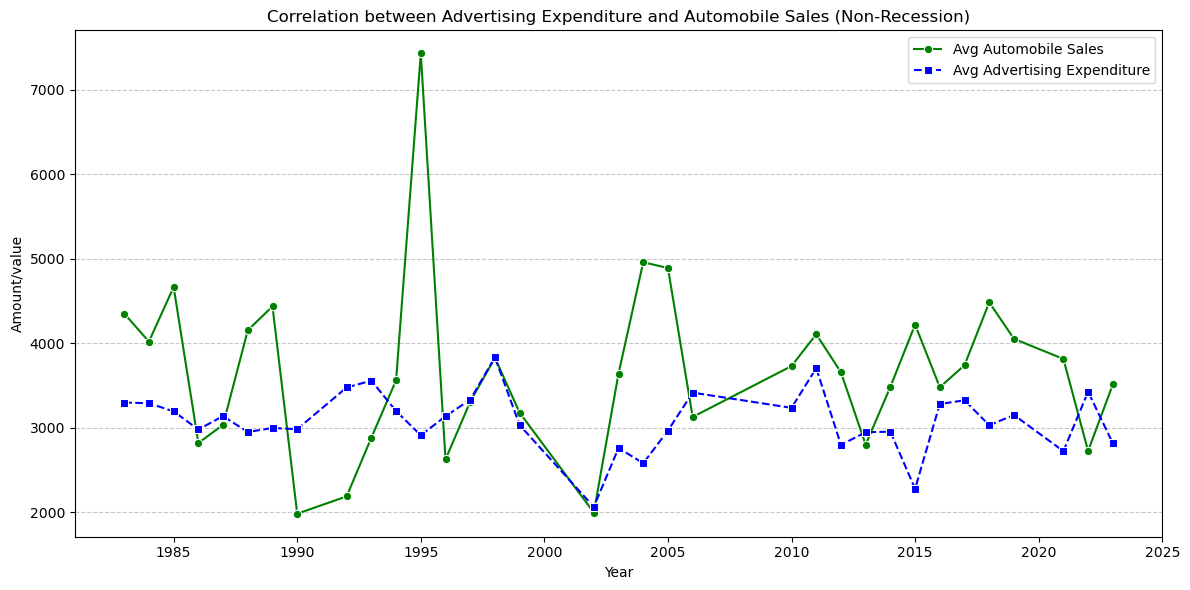

In [17]:
# Assuming 'df' is your dataset
df_non_rec = df[df['Recession'] == 0]

# Calculate average automobile sales and average advertising expenditure by year (non-recession)
df_trends = df_non_rec.groupby("Year", as_index=False).agg(
    Avg_Sales=("Automobile_Sales", 'mean'),
    Avg_Ad_Spend=("Advertising_Expenditure", 'mean')
)

# Create line plots for average sales and advertising expenditure over the years
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_trends, x="Year", y="Avg_Sales", marker='o', linestyle='-', color='green', label="Avg Automobile Sales")
sns.lineplot(data=df_trends, x="Year", y="Avg_Ad_Spend", marker='s', linestyle='--', color='blue', label="Avg Advertising Expenditure")

# Add labels, legend, title, and grid
plt.xlabel("Year")
plt.ylabel("Amount/value")
plt.title("Correlation between Advertising Expenditure and Automobile Sales (Non-Recession)")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()

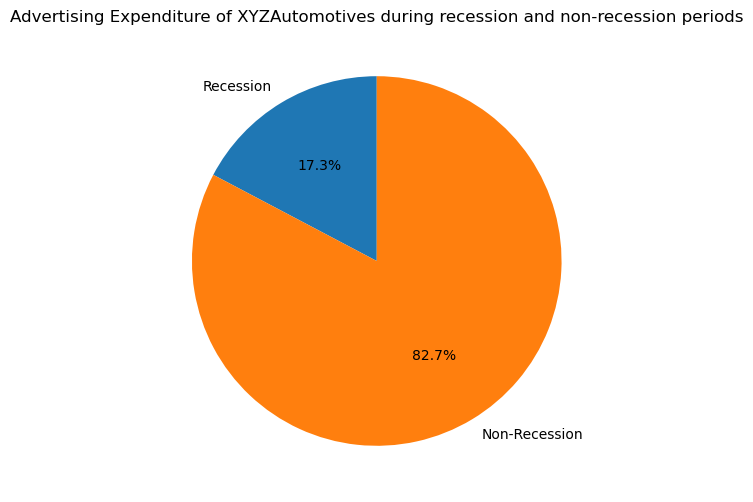

In [18]:
#display the portion of advertising expenditure of XYZAutomotives during recession and non-recession periods.
# Filter the data 
Rdata = df[df['Recession'] == 1]
NRdata = df[df['Recession'] == 0]

# Calculate the total advertising expenditure for both periods
RAtotal = Rdata['Advertising_Expenditure'].sum()
NRAtotal = NRdata['Advertising_Expenditure'].sum()

# Create a pie chart for the advertising expenditure 
plt.figure(figsize=(8, 6))

labels = ['Recession', 'Non-Recession']
sizes = [RAtotal, NRAtotal]
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)

plt.title('Advertising Expenditure of XYZAutomotives during recession and non-recession periods')

plt.show()

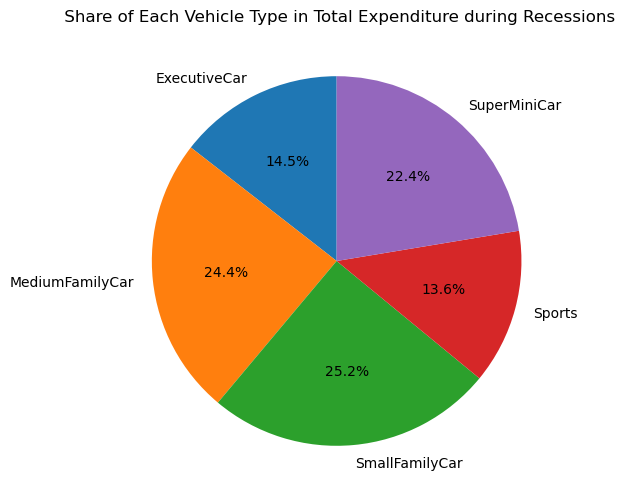

In [19]:
#display the total Advertisement expenditure for each vehicle type during recession period.
# Filter the data 
Rdata = df[df['Recession'] == 1]

# Calculate the sales volume by vehicle type during recessions
VTexpenditure = Rdata.groupby('Vehicle_Type')['Advertising_Expenditure'].sum()

# Create a pie chart for the share of each vehicle type in total expenditure during recessions
plt.figure(figsize=(8, 6))

labels = VTexpenditure.index
sizes = VTexpenditure.values
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)

plt.title(' Share of Each Vehicle Type in Total Expenditure during Recessions')

plt.show()

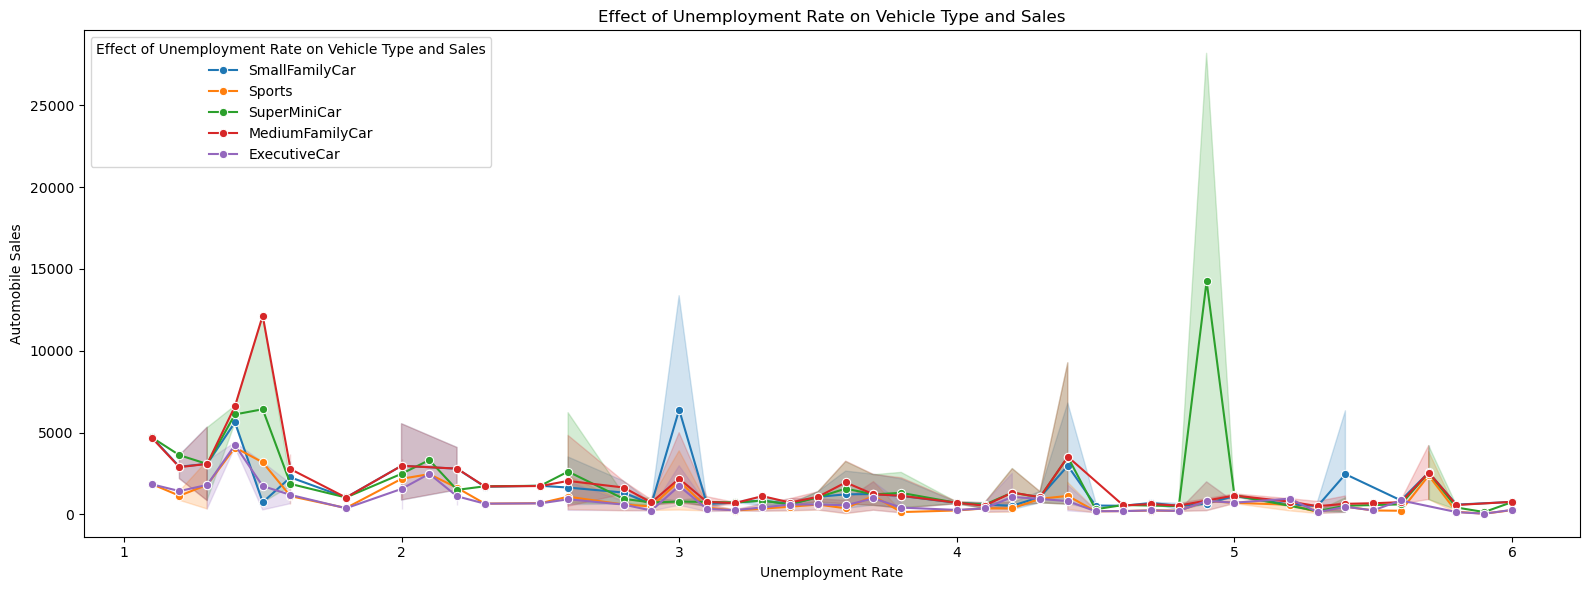

In [21]:
#analyse the effect of the unemployment rate on vehicle type and sales during the Recession Period.
# Assuming 'df' is your dataset
df_rec = df[df['Recession'] == 1]

# Set figure size
plt.figure(figsize=(16, 6))

# Create line plot showing effect of unemployment rate on automobile sales, by vehicle type
sns.lineplot(
    data=df_rec,
    x='unemployment_rate',             
    y='Automobile_Sales',             
    hue='Vehicle_Type',             
    marker='o'
)

# Customize labels, legend, and title
plt.title('Effect of Unemployment Rate on Vehicle Type and Sales')
plt.xlabel('Unemployment Rate')
plt.ylabel('Automobile Sales')
plt.legend(title= 'Effect of Unemployment Rate on Vehicle Type and Sales')

# Show plot
plt.tight_layout()
plt.show()